# Housing model (Version 4.1)
This notebook implements my model as laid out in section 3 and 4 in my thesis 'Housing price disparities and Wealth Inequality in Denmark'.

**Table of contents**<a id='toc0_'></a>    
- 1. [Demographic data](#toc1_)  
- 2. [Solution procedure \& calibration of the 1992 steady state](#toc2_)    
- 3. [Partial equilibrium scenarios: 1992-2070](#toc3_)    
- 4. [IRFs in the linearized model](#toc4_)   
- 6. [A robustness check](#toc6_) 
- 6. [Appendix: Life-cycle profiles from MAKRO](#toc6_) 
- 7. [Appendix: Partial equilibrium and the DC-EGM algorithm](#toc7_)  
- 5. [Appendix: Policy experiments](#toc5_)
- 8. [Appendix: Sequence Space Jacobian using the Fake News machinery](#toc8_)  


Required packages are loaded:

In [1]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
import matplotlib as mpl
import HANCHousingModel
import household_problem
import steady_state
import transition
import blocks
import plots
import calibration
import copy


importlib.reload(HANCHousingModel)
importlib.reload(household_problem)
importlib.reload(steady_state)
importlib.reload(transition)
importlib.reload(blocks)
importlib.reload(plots)

# Setting fonts for plots
plots.set_plot_style(font='Palatino', base_fontsize=12)  


{'font.family': 'Palatino',
 'font.serif': ['Palatino', 'DejaVu Serif'],
 'mathtext.fontset': 'stix',
 'mathtext.rm': 'Palatino',
 'mathtext.it': 'Palatino:italic',
 'mathtext.bf': 'Palatino:bold',
 'axes.titlesize': 14,
 'axes.labelsize': 12,
 'xtick.labelsize': 11,
 'ytick.labelsize': 11,
 'legend.fontsize': 11,
 'figure.titlesize': 15,
 'font.size': 12}

## 1) Demographic data
This section initializes a model as an instance of the HANCHousingModelClass() which is calibrated to the 1992 steady state, and loads demographic data:

In [2]:
importlib.reload(HANCHousingModel)
importlib.reload(steady_state)
importlib.reload(household_problem)
importlib.reload(blocks)
importlib.reload(transition)
import build_cohort_weights as bcw


# a. Initializing the model
model_1992 = HANCHousingModel.HANCHousingModelClass()
model_1992.setup()


# b. Lifecycle dimension (ages 16-64 inclusive)
model_1992.par.J = 64  # j=0 -> age 16, j=64 -> age 80
T_data = 79   # 79 periods: 1992..2070 inclusive
T_pad  = 50 #200
model_1992.par.T = T_data + T_pad
model_1992.allocate()

I load the demographic data from Statistics Denmark for a 78 year transition period for which data is available (1992-2069). This includes cohort weights $\{\omega\}_{k,t\geq 0}$, the scale of households $N_t$ with $N_{1992}$ normalized to 1.0. I further add an extra 100 periods ("T_pad") to avoid truncation error, where cohort sizes and population size is fixed to their 2070 values.

In [ ]:

# a. Load demographic data (1992-2070 in demographics.xlsx):
import build_cohort_weights as bcw
importlib.reload(bcw)
print('build_cohort_weights path:', bcw.__file__)

years_all, people_matrix, cohort_weights_data = bcw.build_cohort_weights_from_xlsx(
    'demographics.xlsx',
    J=model_1992.par.J,
    labor_age_min=16,
)


# b. Building the array of population sizes - normalized to the 1992 population between ages 0 and K
hh_scale_data = people_matrix[:T_data, :].sum(axis=1)
hh_scale_data = hh_scale_data / hh_scale_data[0] 
hh_scale_pad = np.full(T_pad, hh_scale_data[-1]) # After 2070, both paths are fixed at their 2070 values
hh_scale_full = np.concatenate([hh_scale_data, hh_scale_pad])


# c. Padding the cohort weights at the end with the 2070 values (fixed after 2070)
cohort_weights_data = cohort_weights_data[:T_data]                        # (T_data, J), 1992-2070
cohort_weights_pad  = np.tile(cohort_weights_data[-1], (T_pad, 1))         # (T_pad,  J), fixed at 2070
cohort_weights_full = np.concatenate([cohort_weights_data, cohort_weights_pad]) 
assert cohort_weights_full.shape == (model_1992.par.T, model_1992.par.J), \
    f'cohort_weights_full {cohort_weights_full.shape} != ({model_1992.par.T}, {model_1992.par.J})'


# d. Passing the different cohort weights to the model 
model_1992.ss.cohort_weights     = cohort_weights_data[0].copy()
model_1992.par.cohort_weights_ss = cohort_weights_data[0].copy()
model_1992.path.cohort_weights   = cohort_weights_full.copy()
model_1992.par.hh_scale = float(hh_scale_data[0])
model_1992.ss.hh_scale  = float(hh_scale_data[0])

build_cohort_weights path: /Users/felixwohlert/Desktop/Speciale/Code for thesis/GE model/Version 4.1 (main)/build_cohort_weights.py


## 2) Solution procedure \& calibration of the 1992 steady state
This section solves the steady state using $\texttt{find\_ss\_prices()}$, which solves the fixed point:

\begin{align}
      \begin{pmatrix}
        \tilde{q}^u_t(H^{u,hh}_t(q_t^u,q^{r}))-q^u_t \\
        \tilde{q}^r_t(H^{r,hh}_t(q_t^u,q^{r}))-q^r_t
    \end{pmatrix} =0,
\end{align}

In [ ]:

model_1992.par.alpha = 0.30

# a. Initial guesses to aid the solver converge faster
model_1992.ss.q_r = 0.228538  # price of rural housing
model_1992.ss.q_u = 0.464247  # price of urban housing relative to rural
model_1992.ss.f_r = 0.107623  # rent in rural region (per unit of housing service)
model_1992.ss.f_u = 0.218623  # rent in urban region relative to rural
model_1992.ss.w    = 1.227392
model_1992.ss.r    = 0.05592
model_1992.ss.rK = 0.080920

model_1992.ss.H_u = 9.051150
model_1992.ss.H_r = 6.494986
model_1992.ss.H_u_hh = model_1992.ss.H_u   
model_1992.ss.H_r_hh = model_1992.ss.H_r 

model_1992.ss.K = 6.856005
model_1992.ss.K_tilde = 6.23397
model_1992.ss.K_u = 0.495114
model_1992.ss.K_r = 0.126921

model_1992.ss.L = 1.0
model_1992.ss.L_tilde = 0.958990
model_1992.ss.L_u = 0.032642
model_1992.ss.L_r = 0.008368

model_1992.ss.IH_u = 0.227335
model_1992.ss.IH_r = 0.162203
model_1992.ss.I = 0.1714
     
# b. calling the steady state solver
model_1992.find_ss_prices(model_1992, do_print=True)

  call=   1  r=0.05592  w=1.2274  q_u=0.3810  q_r=0.1371  res_q_u=-1.358e-01  res_q_r=+9.584e-02  |res|=1.358e-01
  call=   2  r=0.05592  w=1.2274  q_u=0.3810  q_r=0.1371  res_q_u=-1.358e-01  res_q_r=+9.584e-02  |res|=1.358e-01
  call=   3  r=0.05592  w=1.2274  q_u=0.3810  q_r=0.1371  res_q_u=-1.358e-01  res_q_r=+9.584e-02  |res|=1.358e-01
  call=   4  r=0.05592  w=1.2274  q_u=0.3810  q_r=0.1371  res_q_u=-1.358e-01  res_q_r=+9.584e-02  |res|=1.358e-01
  call=   5  r=0.05592  w=1.2274  q_u=0.3810  q_r=0.1371  res_q_u=-1.358e-01  res_q_r=+9.584e-02  |res|=1.358e-01
  call=   6  r=0.05592  w=1.2274  q_u=0.3269  q_r=0.1494  res_q_u=+2.606e-02  res_q_r=+8.227e-04  |res|=2.606e-02
  call=   7  r=0.05592  w=1.2274  q_u=0.3356  q_r=0.1496  res_q_u=-7.748e-04  res_q_r=+1.797e-04  |res|=7.748e-04
  call=   8  r=0.05592  w=1.2274  q_u=0.3353  q_r=0.1496  res_q_u=-2.449e-05  res_q_r=+1.550e-05  |res|=2.449e-05
  call=   9  r=0.05592  w=1.2274  q_u=0.3353  q_r=0.1496  res_q_u=-6.922e-07  res_q_r=+7

(True, array([0.05592   , 1.22739176]))

This cell reports on reports on the key model moments reported in Table 4.2.

In [ ]:
from calibration import report
importlib.reload(calibration)
report(model=model_1992)


  Moment                                 Model   Target    Dev %
  ----------------------------------------------------------------
  Urban/rural price ratio               2.2414   1.5284   +46.65%  ✗
  Urban population share                0.2769   0.3000    -7.70%  ✗
  Share of renters - Urban region       0.3465   0.3720    -6.86%  ✗
  Share of renters - Rural region       0.5992   0.5560    +7.76%  ✗
  Urban construction/GDP                0.0275   0.0028  +893.36%  ✗
  Rural construction/GDP                0.0168   0.0174    -3.88%  ✓
  Middle 40% wealth share               0.5788   0.4641   +24.72%  ✗
  Bottom 50% wealth share               0.1020  -0.0074 -1475.98%  ✗

  Wealth ratios
  Moment                                 Model     Data    Dev %
  ----------------------------------------------------------------
  Capital/GDP                           3.6142   3.6975    -2.25%  ✓
  Urban housing/GDP                     1.0997   0.0006 +186905.89%  ✗
  Rural housing/GDP       

$\texttt{find\_ss\_prices()}$ method is called upon by $\texttt{calibration.py}$, which calibrates the model to the 1992 steady state by calling a Nelder-Mead optimizer, internally calibrating a subset of parameters as described in section 4.4 of the thesis.

In [6]:
importlib.reload(steady_state)
importlib.reload(calibration)
from calibration import calibrate


# a. Calibration specs for parameters- (initial guess, lower bound, upper bound)
PARAM_SPEC_FIXED = {    
    'kappa': (-0.697248, -5.0, 25.0),
    'h_u': (28.5612, 1.0, 40.0),
    'h_r': (13.4599, 1.0, 40.0),
    'h_l': (10.456, 1.0, 20.0),
    'beta': (0.932612, 0.91, 0.99),
    'sigma_psi': (0.12723, 0.1, 0.3),
    'mu_1': (0.429555, 0.0, 0.75),
}


# b. Moment weights in the objective function 
TARGET_SPEC = {
    'Urban/rural price ratio': 1.0,
    'Urban population share':  1.0,
    'Share of renters - Urban region': 1.0,
    'Share of renters - Rural region': 1.0,
    'Urban construction/GDP':  1.0,
    'Rural construction/GDP':  1.0,
    'Middle 40% wealth share':  1.0,
    'Bottom 50% wealth share': 1.0,
}


# c. Bounds on the model moments (upper, lower)
MOMENT_BOUNDS_FIXED = {
    'Urban/rural price ratio': (1.0, 3.0),
    'Urban population share': (0.20, 0.50),
    'Share of renters - Urban region': (0.00, 1.00),
    'Share of renters - Rural region': (0.00, 1.00),
    'Urban construction/GDP': (0.0015, 0.10),
    'Rural construction/GDP': (0.003,  0.10),
    'Middle 40% wealth share': (0.30, 0.65),
    'Bottom 50% wealth share': (0.0, 0.50),
}


# d. calling the Nelder-Mead calibraiton routine
result, x_cal, moments_cal, param_names = calibration.calibrate(
    model_1992,
    param_spec=PARAM_SPEC_FIXED,
    target_spec=TARGET_SPEC,
    moment_bounds=MOMENT_BOUNDS_FIXED,
    data_path='datagraphs.xlsx',
    base_year=1992,
    maxiter=50,
    max_evals=1,
    verbose=True,
)


#calibrate(model_1992, do_print=True)

Active calibration targets:
  Urban/rural price ratio             1.5284  (w = 1.0)
  Urban population share              0.3000  (w = 1.0)
  Share of renters - Urban region     0.3720  (w = 1.0)
  Share of renters - Rural region     0.5560  (w = 1.0)
  Urban construction/GDP              0.0028  (w = 1.0)
  Rural construction/GDP              0.0174  (w = 1.0)
  Middle 40% wealth share             0.4641  (w = 1.0)
  Bottom 50% wealth share             0.0000  (w = 1.0)

Calibrating 7 parameter(s): ['kappa', 'h_u', 'h_r', 'h_l', 'beta', 'sigma_psi', 'mu_1']
Against     8 moment(s)

  Initial loss (x0) = 8.0117e+01

CALIBRATION RESULT
  Converged : False  —  Maximum number of function evaluations has been exceeded.
  Objective : 8.0117e+01
  Iterations: 1  (func evals: 1)

  Parameter                Original   Calibrated
  ----------------------------------------------
  kappa                     -0.6972      -0.6972
  h_u                       28.5612      28.5612
  h_r               

## 3) Comparative statics in steady state
This section implements the comparative statics of section 5.1. The central function used is $\texttt{comparative\_statics\_tenure\_supply\_demand()}$, which solves the household problem using $\texttt{solve\_hh\_ss()}$ and $\texttt{simulate\_hh\_ss\_olg()}$ for different prices and also plots the supply curve in the respective regions.

In [116]:
importlib.reload(steady_state)
from steady_state import comparative_statics_tenure_supply_demand
import plots
importlib.reload(plots)


# a. calling the comparative statics function for the four different shocks
all_data = {
    'r_world':        steady_state.comparative_statics_tenure_supply_demand(
                          model_1992, shock='r_world', n_points=25,
                          rel_price_span=(2.0, 0.5), shock_size=-0.3390), #a 33.9% decline corresponds to a 1 pp drop
    'hh_scale':       steady_state.comparative_statics_tenure_supply_demand(
                          model_1992, shock='hh_scale', n_points=25,
                          rel_price_span=(2.0, 0.5), shock_size=+0.10),
    'cohort_weights': steady_state.comparative_statics_tenure_supply_demand(
                          model_1992, shock='cohort_16_36', n_points=25,
                          rel_price_span=(2.0, 0.5), shock_size=-0.20),
    'kappa':          steady_state.comparative_statics_tenure_supply_demand(
                          model_1992, shock='kappa', n_points=25,
                          rel_price_span=(2.0, 0.5), shock_size=+0.50),
}



This cell draws the comparative static figures of Figures 5.1-5.4:

/Users/felixwohlert/Desktop/Speciale/Code for thesis/GE model/Version 4.1 (main)/plots.py:1840: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


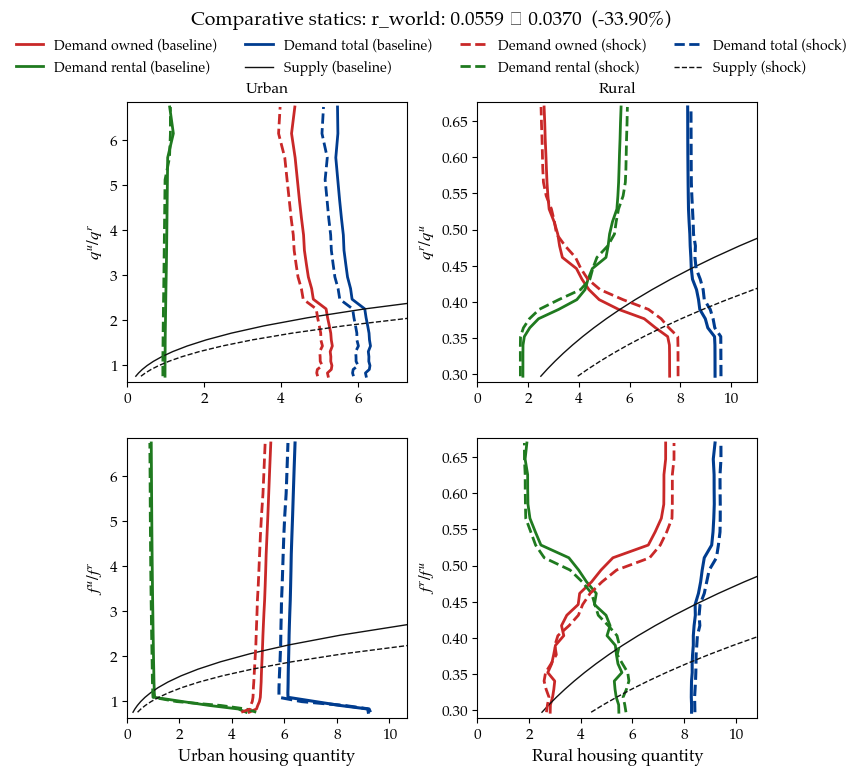

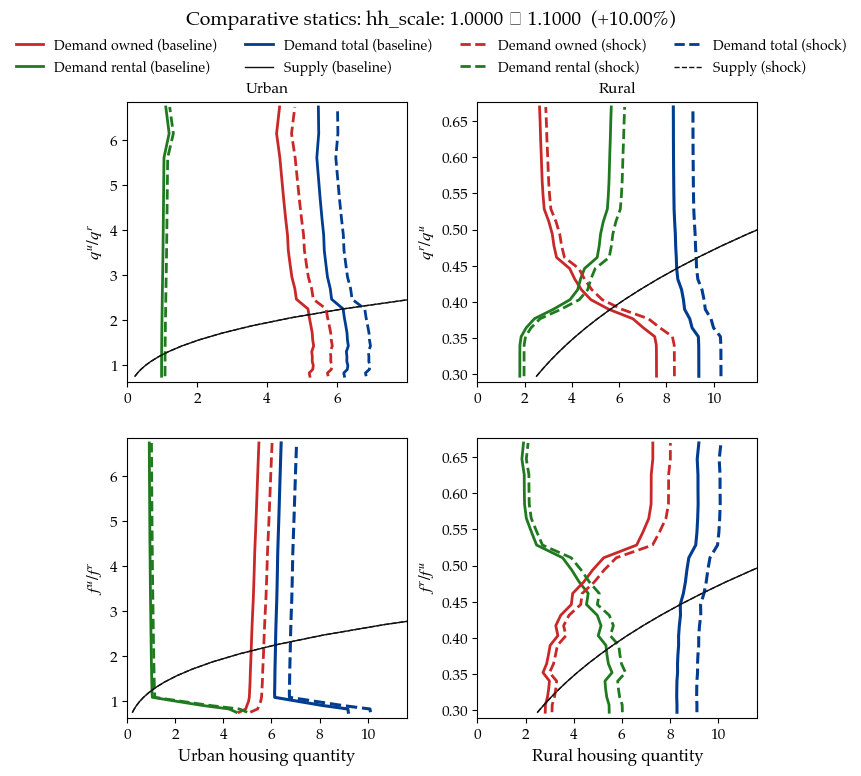

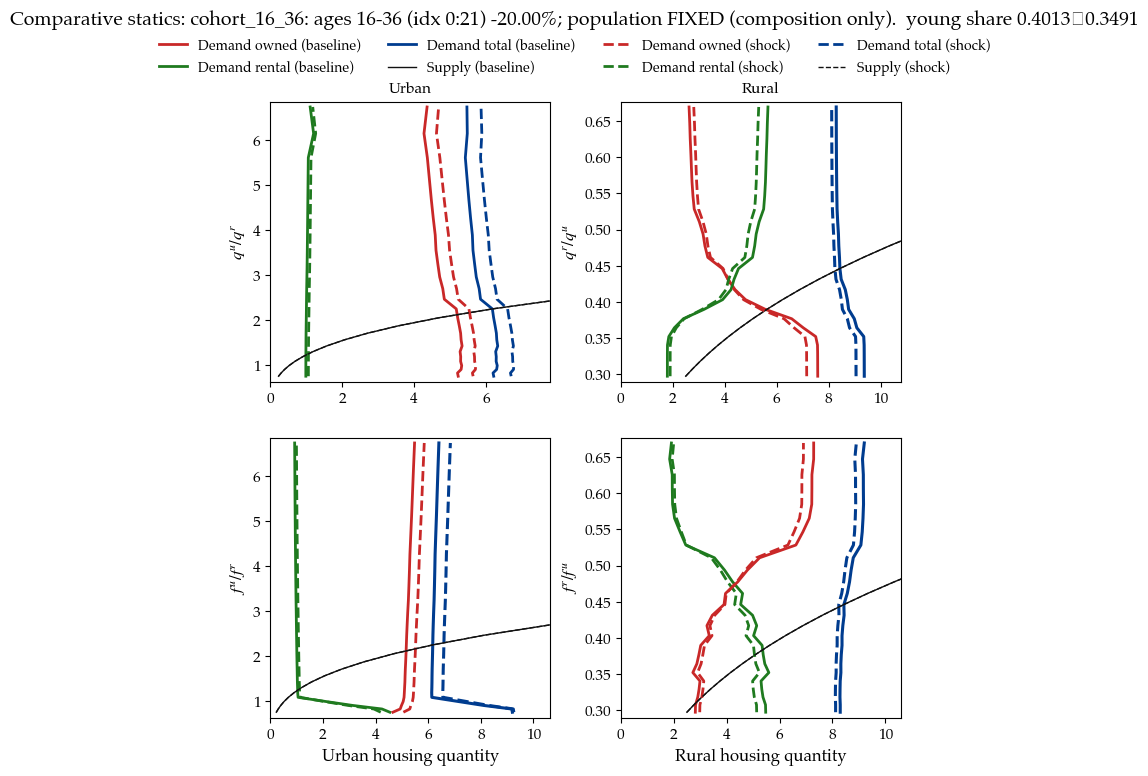

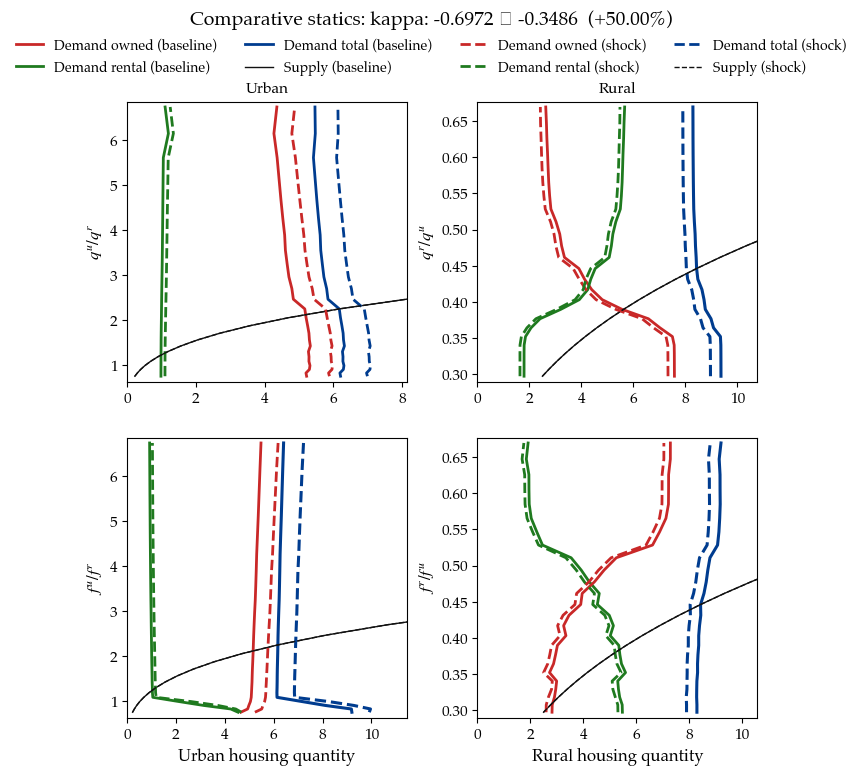

In [117]:
import plots
importlib.reload(plots)

# a. plotting the comparative statics
for name, data in all_data.items():                                
    plots.plot_comparative_statics_tenure_supply_demand(
        data=data,                                                 
        title=f'Comparative statics: {data["shock_desc"]}',
    )


## 4) Partial equilibrium scenarios: 1992-2070

I will set up different scenarios for the interest rate, wages, housing prices and the urban preference parameter.

First, the price data is loaded from $\texttt{datagraphs.xlsx}$.


In [14]:

# a. Importing the data for each price series
import openpyxl as _openpyxl
_wb = _openpyxl.load_workbook('datagraphs.xlsx', data_only=True)
_ws = _wb.active
_headers = [c.value for c in _ws[1]]
_col_rate = _headers.index('Real rate')
_col_wage = _headers.index('Wage')
_col_q_u = _headers.index('Urban price')
_col_q_r = _headers.index('Rural price')


# b. Extracting the annual data and transforming appropriately - I reindex the data to match the model's steady state values
_real_rate_data = model_1992.ss.r * np.array(
    [row[_col_rate] for row in _ws.iter_rows(min_row=2, values_only=True) if row[_col_rate] is not None],
    dtype=float,
) / 5.59

_real_wage_data = model_1992.ss.w * np.array(
    [row[_col_wage] for row in _ws.iter_rows(min_row=2, values_only=True) if row[_col_wage] is not None],
    dtype=float,
) / 99.76 # reindexing since the HP-filter bumped the index away from 100

_urban_housing_price_data = model_1992.ss.q_u * np.array(
    [row[_col_q_u] for row in _ws.iter_rows(min_row=2, values_only=True) if row[_col_q_u] is not None],
    dtype=float,
) / 5541.71

_rural_housing_price_data = model_1992.ss.q_r * np.array(
    [row[_col_q_r] for row in _ws.iter_rows(min_row=2, values_only=True) if row[_col_q_r] is not None],
    dtype=float,
) / 3874.55

Different scenarios for 2024-2070 price paths are then set up (for an overview of the scenarios, see Table 5.1 in the thesis)

In [ ]:
# a. Build full-length scenario paths with three segments:
def _exp_ramp_to_target(x0, xT, n):
    if n <= 0:
        return np.array([], dtype=float)
    tau = np.linspace(0.0, 1.0, n + 1)[1:]
    if x0 > 0.0 and xT > 0.0:
        return x0 * (xT / x0) ** tau
    return np.linspace(x0, xT, n + 1)[1:]


def _build_full_path_from_data(obs, terminal_value, year_start=1992, year_data_end=2024):
    obs = np.asarray(obs, dtype=float).ravel()
    years_obs = year_start + np.arange(obs.size)

    if year_data_end not in years_obs:
        raise ValueError(f'Data must include year {year_data_end}.')

    i_end = int(np.where(years_obs == year_data_end)[0][-1])
    obs_1992_2024 = obs[:i_end + 1]

    # Number of years from 2025..2070 inside data window
    n_to_2070 = int(T_data - obs_1992_2024.size)
    if n_to_2070 < 0:
        raise ValueError('Observed sample is longer than T_data.')

    trans_2025_2070 = _exp_ramp_to_target(obs_1992_2024[-1], float(terminal_value), n_to_2070)
    flat_post_2070 = np.full(T_pad, float(terminal_value), dtype=float)

    full = np.concatenate([obs_1992_2024, trans_2025_2070, flat_post_2070])
    assert full.size == model_1992.par.T
    return full


# b. Terminal values (edit as desired)
r_terminal_low = 0.001
r_terminal_high = 0.040
r_terminal_base = 0.5 * (r_terminal_low + r_terminal_high)

w_terminal = (_real_wage_data[-1]) * ((1 + 0.0095) ** (2070-2024)) # wage growth of approx. 0.95 per cent since 2024

q_u_terminal_low = 1.000 * _urban_housing_price_data[min(len(_urban_housing_price_data) - 1, np.where((1992 + np.arange(len(_urban_housing_price_data))) == 2024)[0][-1])]
q_u_terminal_high = 13.504 * _urban_housing_price_data[min(len(_urban_housing_price_data) - 1, np.where((1992 + np.arange(len(_urban_housing_price_data))) == 2024)[0][-1])]
q_u_terminal_base = 0.5 * (q_u_terminal_low + q_u_terminal_high)

q_r_terminal_low = 1.000 * _rural_housing_price_data[min(len(_rural_housing_price_data) - 1, np.where((1992 + np.arange(len(_rural_housing_price_data))) == 2024)[0][-1])]
q_r_terminal_high = 8.333 * _rural_housing_price_data[min(len(_rural_housing_price_data) - 1, np.where((1992 + np.arange(len(_rural_housing_price_data))) == 2024)[0][-1])]
q_r_terminal_base = 0.5 * (q_r_terminal_low + q_r_terminal_high)    


# c. Full-length arrays (names kept as requested)
r_tail_low = _build_full_path_from_data(_real_rate_data, r_terminal_low)
r_tail_high = _build_full_path_from_data(_real_rate_data, r_terminal_high)
r_tail_base = _build_full_path_from_data(_real_rate_data, r_terminal_base)

w_tail = _build_full_path_from_data(_real_wage_data, w_terminal)

q_u_tail_low = _build_full_path_from_data(_urban_housing_price_data, q_u_terminal_low)
q_u_tail_high = _build_full_path_from_data(_urban_housing_price_data, q_u_terminal_high)
q_u_tail_base = _build_full_path_from_data(_urban_housing_price_data, q_u_terminal_base)

q_r_tail_low = _build_full_path_from_data(_rural_housing_price_data, q_r_terminal_low)
q_r_tail_high = _build_full_path_from_data(_rural_housing_price_data, q_r_terminal_high)
q_r_tail_base = _build_full_path_from_data(_rural_housing_price_data, q_r_terminal_base)



# d. Kappa scenarios (1992-2024 data-informed anchor, then geometric decay to 2070, then flat)
def _kappa_path_scenario(k_2024, k_2070):
    k0 = float(model_1992.par.kappa)
    n_data = 33  # 1992..2024 inclusive
    n_to_2070 = T_data - n_data

    k_data = np.linspace(k0, float(k_2024), n_data)
    k_trans = _exp_ramp_to_target(k_data[-1], float(k_2070), n_to_2070)
    k_flat = np.full(T_pad, float(k_2070), dtype=float)
    k_full = np.concatenate([k_data, k_trans, k_flat])
    assert k_full.size == model_1992.par.T
    return k_full

kappa_low = _kappa_path_scenario(-0.1, -0.1)
kappa_high = _kappa_path_scenario(-0.1, 2.0)
kappa_base = 0.5 * (kappa_low + kappa_high)


# d. Scenario dictionaries (all length T)
real_rate_paths_data = {
    'low': r_tail_low,
    'high': r_tail_high,
    'baseline': r_tail_base,
}

wage_paths_data = {
    'base': w_tail,
}

q_paths_data = {
    'low': q_u_tail_low,
    'high': q_u_tail_high,
    'baseline': q_u_tail_base,
}

q_r_paths_data = {
    'low': q_r_tail_low,
    'high': q_r_tail_high,
    'baseline': q_r_tail_base,
}

kappa_paths_data = {
    'low': kappa_low,
    'high': kappa_high,
    'baseline': kappa_base,
}



In [ ]:
import simulation as sim
importlib.reload(sim)

# a. Here I am setting up the baseline scenario as well as different permutations of the different scenarios reported in tabel 5.1, which generates the grey fans
baseline_scenario = {
    'r':     real_rate_paths_data['baseline'],
    'w':     wage_paths_data['base'],
    'q_u':   q_paths_data['baseline'],
    'q_r':   q_r_paths_data['baseline'],
    'kappa': kappa_paths_data['baseline'],
}

scenario_1 = {
    'r':     real_rate_paths_data['high'],
    'w':     wage_paths_data['base'],
    'q_u':   q_paths_data['high'],
    'q_r':   q_r_paths_data['low'],
    'kappa': kappa_paths_data['high'],
}

scenario_2 = {
    'r':     real_rate_paths_data['high'],
    'w':     wage_paths_data['base'],
    'q_u':   q_paths_data['high'],
    'q_r':   q_r_paths_data['high'],
    'kappa': kappa_paths_data['high'],
}

scenario_3 = {
    'r':     real_rate_paths_data['high'],
    'w':     wage_paths_data['base'],
    'q_u':   q_paths_data['low'],
    'q_r':   q_r_paths_data['high'],
    'kappa': kappa_paths_data['low'],
}

scenario_4 = {
    'r':     real_rate_paths_data['low'],
    'w':     wage_paths_data['base'],
    'q_u':   q_paths_data['high'],
    'q_r':   q_r_paths_data['low'],
    'kappa': kappa_paths_data['high'],
}

scenario_5 = {
    'r':     real_rate_paths_data['low'],
    'w':     wage_paths_data['base'],
    'q_u':   q_paths_data['high'],
    'q_r':   q_r_paths_data['high'],
    'kappa': kappa_paths_data['high'],
}

scenario_6 = {
    'r':     real_rate_paths_data['low'],
    'w':     wage_paths_data['base'],
    'q_u':   q_paths_data['low'],
    'q_r':   q_r_paths_data['high'],
    'kappa': kappa_paths_data['low'],
}

scenario_7 = {
    'r':     real_rate_paths_data['low'],
    'w':     wage_paths_data['base'],
    'q_u':   q_paths_data['low'],
    'q_r':   q_r_paths_data['low'],
    'kappa': kappa_paths_data['low'],
}

scenario_8 = {
    'r':     real_rate_paths_data['high'],
    'w':     wage_paths_data['base'],
    'q_u':   q_paths_data['low'],
    'q_r':   q_r_paths_data['low'],
    'kappa': kappa_paths_data['low'],
}

runs = sim.run_scenarios(
    model_1992,
    {'baseline': baseline_scenario,
     'scenario_1': scenario_1,
     'scenario_2': scenario_2,
     'scenario_3': scenario_3,
     'scenario_4': scenario_4,
     'scenario_5': scenario_5,
     'scenario_6': scenario_6,
     'scenario_7': scenario_7,
     'scenario_8': scenario_8
     },
    include_baseline=False,
    n_nw_bins=400,
    year0=1992,
)



  scenario: baseline ...


  scenario: scenario_1 ...
  scenario: scenario_2 ...
  scenario: scenario_3 ...
  scenario: scenario_4 ...
  scenario: scenario_5 ...
  scenario: scenario_6 ...
  scenario: scenario_7 ...
  scenario: scenario_8 ...


This cell plots Figure 5.5 and 5.6 in the thesis.

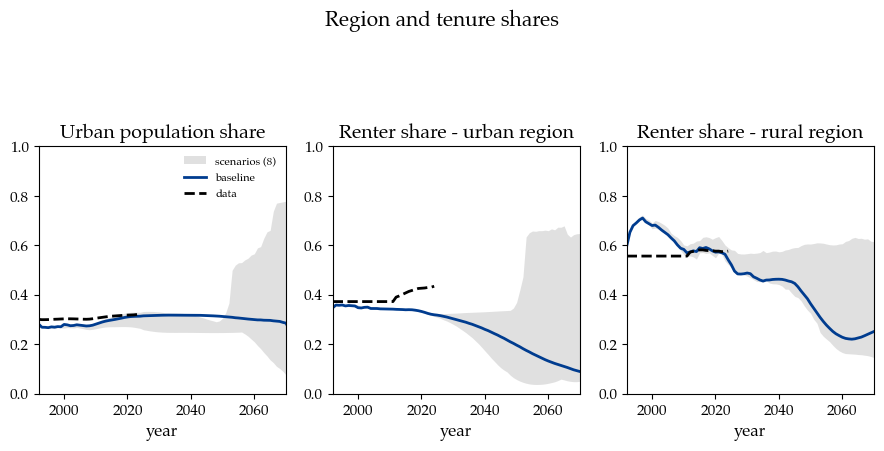

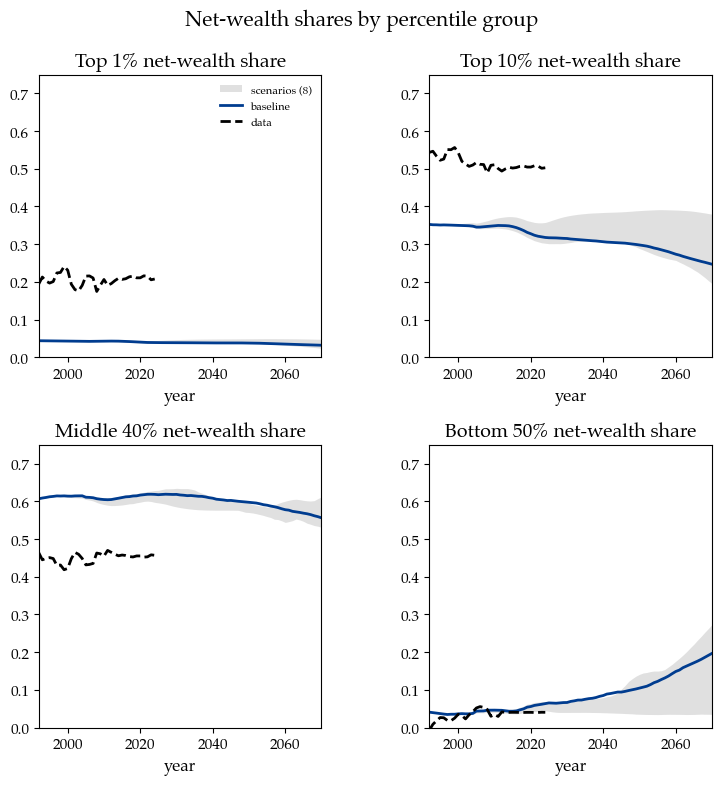

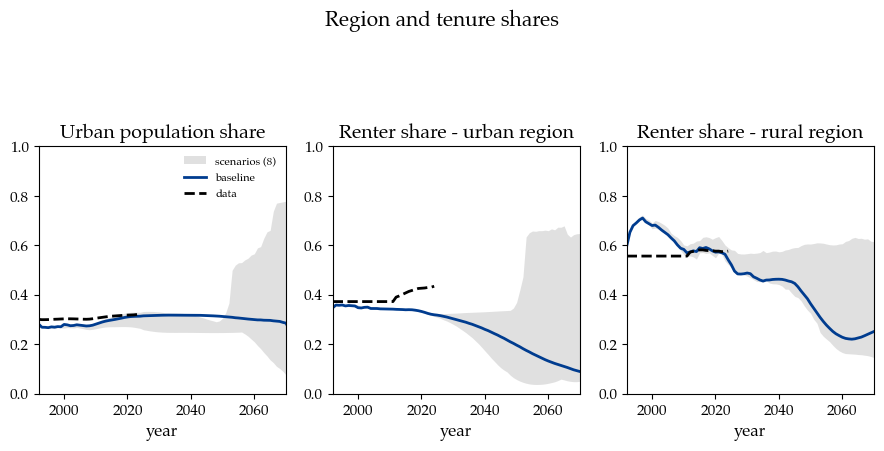

In [ ]:
import simulation as sim
importlib.reload(sim)

sim.plot_wealth_percentiles(runs, xlim=(1992, 2070),ma=0)
sim.plot_region_tenure(runs, xlim=(1992, 2070))

This cell plots Tables 5.2 and 5.3 in thesis:

In [18]:

dec = sim.wealth_growth_decomposition(
    runs['baseline']['pe'],          
    model_1992, as_share=False, year0=1992, year_end=2024)



  Table 5.1 - by net-wealth group
  (1992-2024, wealth growth, per capita, % of 1992 net wealth)
                           %-growth                            %-growth
  group               due to saving    Assets   Housing  due to returns    Assets   Housing     Total
  -------------------------------------------------------------------------------------------------
  Mean                       -28.79    -30.39      1.61           89.63     79.77      9.85     60.84
  Top 10%                    -40.13    -40.25      0.12           85.08     80.73      4.35     44.95
  Mid. 40%                   -27.10    -28.41      1.31           90.94     80.08     10.86     63.84
  Bot. 50%                    43.41     24.72     18.69          109.13     67.02     42.11    152.54

  Table 5.2 - by region x tenure
  (1992-2024, wealth growth, per capita, % of 1992 net wealth)
                           %-growth                            %-growth
  group               due to saving    Assets   Hou

This cell plots Figure 5.6 in the thesis.

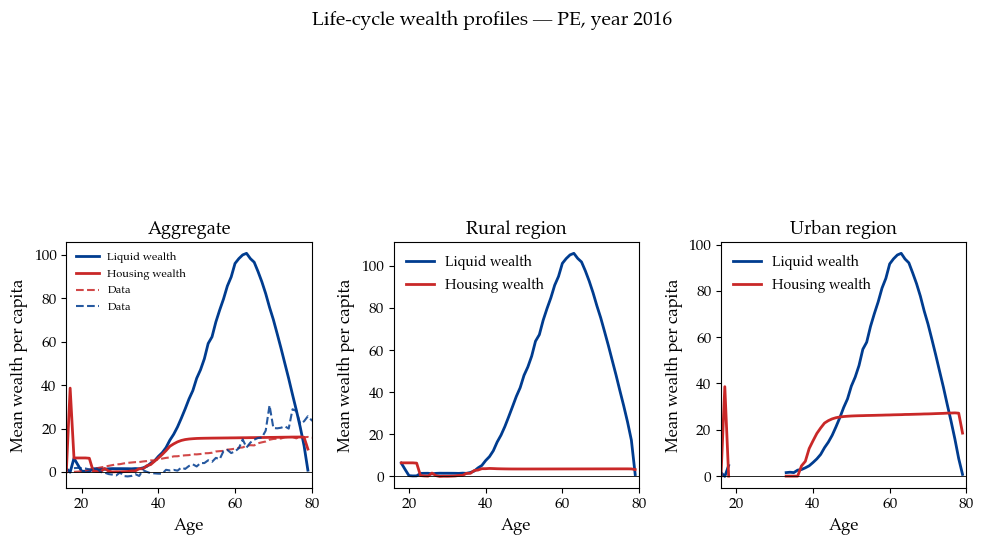

In [74]:
import importlib, plots
importlib.reload(plots)

# Wealth lifecycle for the baseline run, sliced at 2024
plots.plot_lifecycle_wealth_pe(
    runs['baseline']['pe'],
    model_1992,
    year=2016,
    scenario=baseline_scenario,    # ← pulls q_u / q_r from here, not from pe
)



Next, I decompose the 1992-2024 housing wealth stock into exogenous channels.

In [ ]:
import simulation as sim
importlib.reload(sim)

# a. Making sure both demographic channels are in the baseline
baseline_scenario['cohort_weights'] = cohort_weights_full           # (T, J)
baseline_scenario['hh_scale']       = hh_scale_full                 # (T,)

# b. Four counterfactuals: each holds one driver fixed at its 1992 value

# c. kappa fixed at its 1992 value throughout
scenario_kappa_fixed = copy.deepcopy(baseline_scenario)
scenario_kappa_fixed['kappa'] = np.full_like(
    kappa_paths_data['baseline'], model_1992.par.kappa)

# d. real interest rate fixed at its 1992 value
scenario_real_rate_fixed = copy.deepcopy(baseline_scenario)
scenario_real_rate_fixed['r'] = np.full_like(
    real_rate_paths_data['baseline'], model_1992.par.r)

# e. demographic composition (age structure) fixed at 1992
scenario_demographics_fixed = copy.deepcopy(baseline_scenario)
scenario_demographics_fixed['cohort_weights'] = np.tile(
    cohort_weights_data[0], (model_1992.par.T, 1))

# f. population size fixed at 1992
scenario_pop_size_fixed = copy.deepcopy(baseline_scenario)
scenario_pop_size_fixed['hh_scale'] = np.full_like(
    hh_scale_full, model_1992.par.hh_scale)

# g. urban/rural price ratio fixed at 1992 (by fixing both q_u and q_r at their 1992 values)
scenario_price_ratio_fixed = copy.deepcopy(baseline_scenario)
scenario_price_ratio_fixed['q_u'] = np.full_like(
    q_paths_data['baseline'], model_1992.ss.q_u)
scenario_price_ratio_fixed['q_r'] = np.full_like(
    q_r_paths_data['baseline'], model_1992.ss.q_r)  

# h. wage path fixed at 1992
scenario_wage_fixed = copy.deepcopy(baseline_scenario)
scenario_wage_fixed['w'] = np.full_like(
wage_paths_data['base'], model_1992.ss.w)



# i. Bundle and run
decomposition_scenarios = {
    'baseline':                      baseline_scenario,
    'kappa fixed':                   scenario_kappa_fixed,
    'real rate fixed':               scenario_real_rate_fixed,
    'demographic composition fixed': scenario_demographics_fixed,
    'population size fixed':         scenario_pop_size_fixed,
    'price ratio fixed':             scenario_price_ratio_fixed,
    'wage fixed':                    scenario_wage_fixed,
}

runs_decomp = sim.run_scenarios(
    model_1992, decomposition_scenarios,
    include_baseline=False,        # 'baseline' is named explicitly above
    n_nw_bins=400, year0=1992,
)


Here I plot Figure 5.8 in the thesis:

<>:11: SyntaxWarning: invalid escape sequence '\{'
<>:11: SyntaxWarning: invalid escape sequence '\{'
/var/folders/nw/4t6rm3rn4r705nf30vzcz1xw0000gn/T/ipykernel_19374/1371056720.py:11: SyntaxWarning: invalid escape sequence '\{'
  'demographic composition fixed':'Composition $\{\omega_{k,t}\}_{k,t}$ fixed',


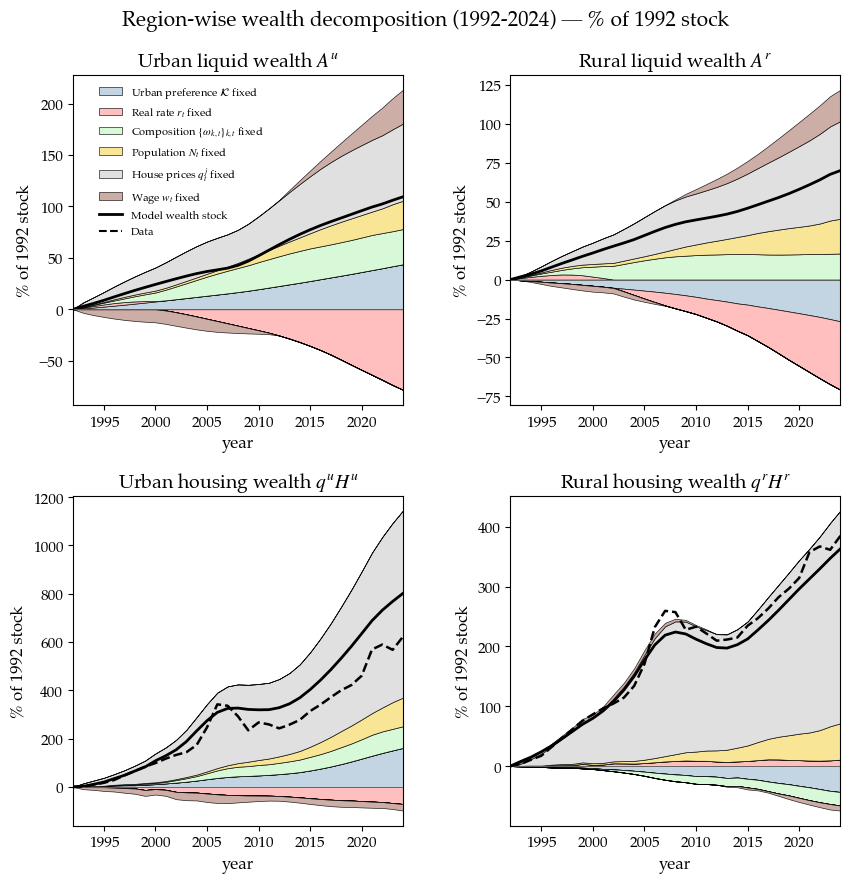

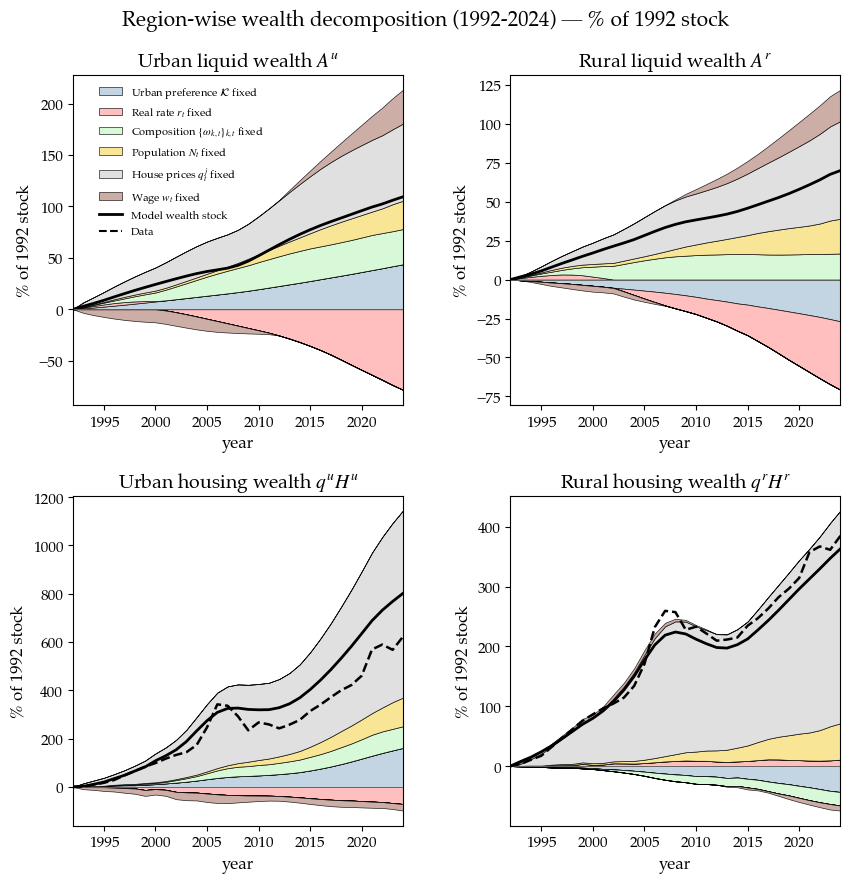

In [102]:
importlib.reload(sim)
importlib.reload(plots)


sim.plot_region_wealth_stocks(runs_decomp, model_1992, year0=1992, year_end=2024,
                              baseline_name='baseline', normalize='pct_ss',
                              figsize=(9, 9),     colors=["#b9cedd", "#ffb4b4", "#d1f8d1", "#f8e184", "#dbdbdbdc", "#c5a098"], 
    legend_labels={
        'kappa fixed':                  r'Urban preference $\mathcal{K}$ fixed',
        'real rate fixed':              r'Real rate $r_t$ fixed',
        'demographic composition fixed':'Composition $\{\omega_{k,t}\}_{k,t}$ fixed',
        'population size fixed':         'Population $N_t$ fixed',
        'price ratio fixed':            r'House prices $q_t^j$ fixed',
        'wage fixed':                    r'Wage $w_t$ fixed',
        'baseline':                      'Model wealth stock',
        'data': 'Data',
    },
    legend_bbox=(0.05, 1.0),   # nudge left of the panel; tune the x
    legend_loc='upper left',
)

## 5) Linearized impulse-response functions
This section implements the linearized impulse-response functions of section 5.3 in the thesis, and computes the cumulative multipliers \& GE wedges which are used to qualify the partial equilibrium simulations in the section above. Since the sequence space Jacobian of the system is computed using the direct method taking approximately 10 hours to run, I included a copy of it in the replication file ($\texttt{H\_U\_full.npy}$)

In [ ]:
import transition
importlib.reload(transition)
import plots
importlib.reload(plots)

from transition import compute_H_U_full   
from transition import make_demographic_shock
from transition import linear_irf
from plots import plot_irf


# a. warning: compute_H_U_full is a ten hour run - uncomment the following line to run
#compute_H_U_full(model_1992, dx=1e-4, save_path='H_U_full.npy', do_print=True)


# b. import the included Jacobian to recreate results
model_1992.H_U = np.load('H_U_full.npy')
print(f'loaded H_U: shape {model_1992.H_U.shape}, cond {np.linalg.cond(model_1992.H_U):.2e}')


# c. compute linearized IRFs
T = model_1992.par.T

irf_r     = linear_irf(model_1992, 'r_world',  -0.01 * 0.95**np.arange(T), tikhonov=0.0)
irf_kappa = linear_irf(model_1992, 'kappa',    0.01   * 0.95**np.arange(T), tikhonov=0.0)
irf_pop   = linear_irf(model_1992, 'hh_scale', 0.01   * 0.95**np.arange(T), tikhonov=0.0)
irf_demo  = linear_irf(model_1992, 'cohort_weights', make_demographic_shock(model_1992, eps=-0.01, rho=0.95), tikhonov=0.0)

This cell plots figure 5.9 for the shock to the real interest rate along with the corresponding figures for the remaining figures in the appendix:

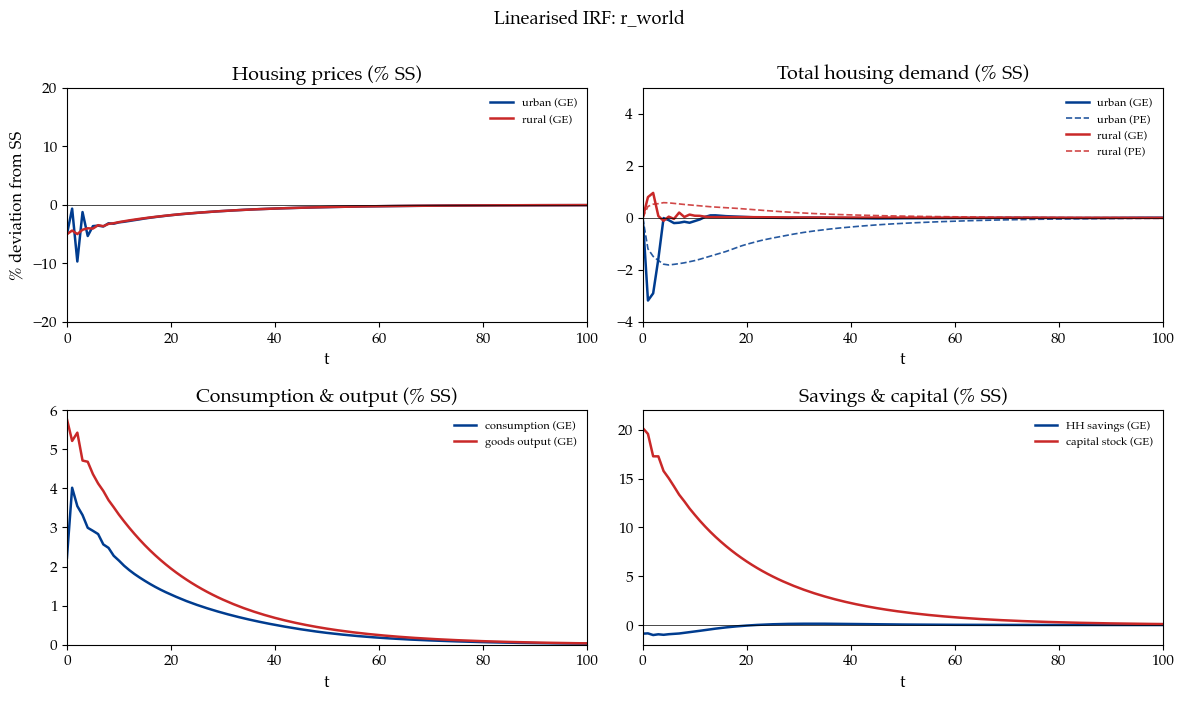

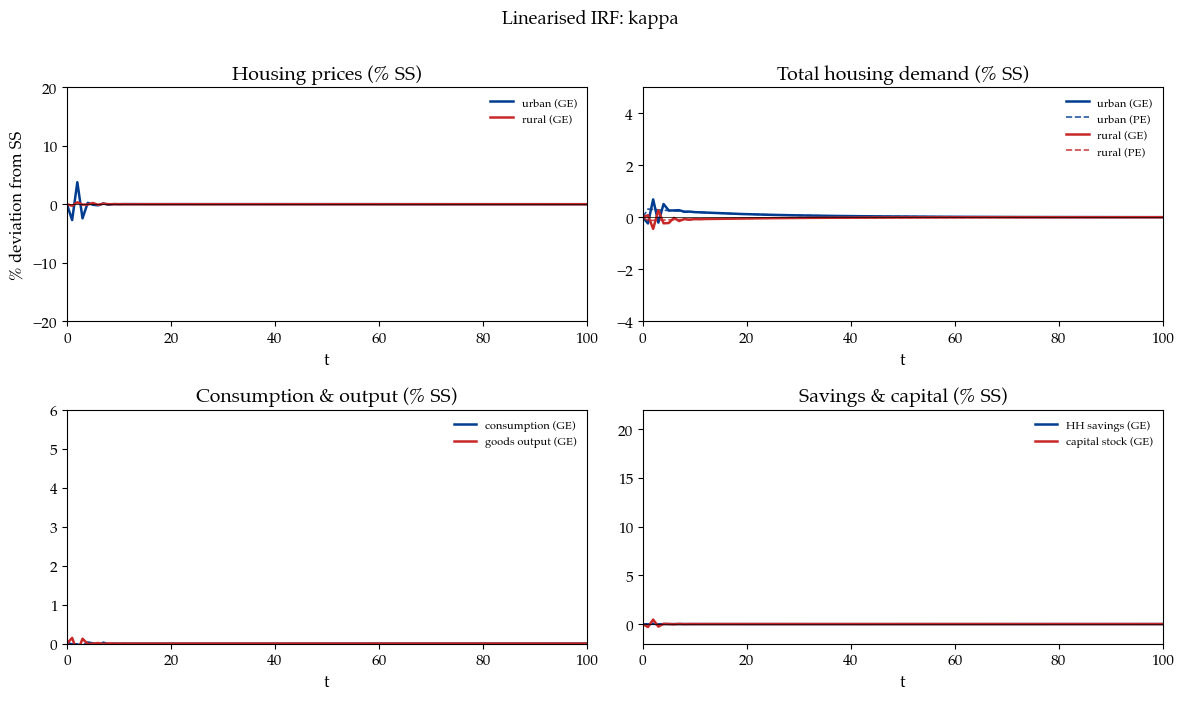

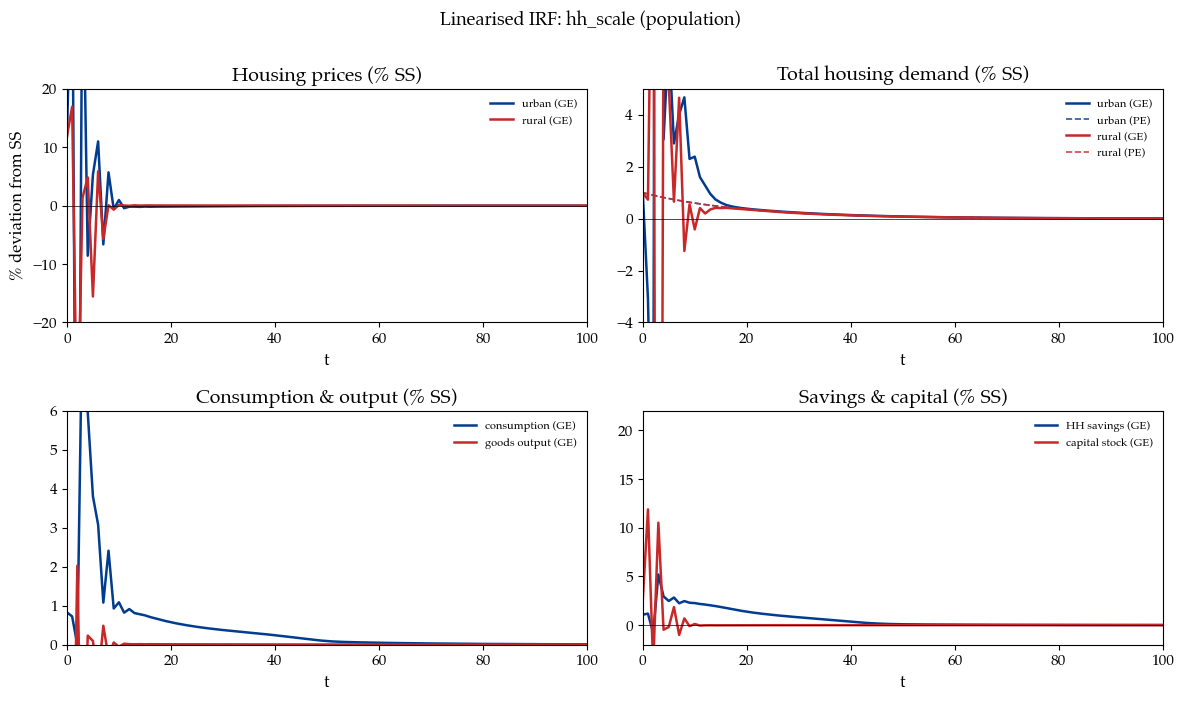

/Users/felixwohlert/Desktop/Speciale/Code for thesis/GE model/Version 4.1 (main)/plots.py:1514: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from current font.
  


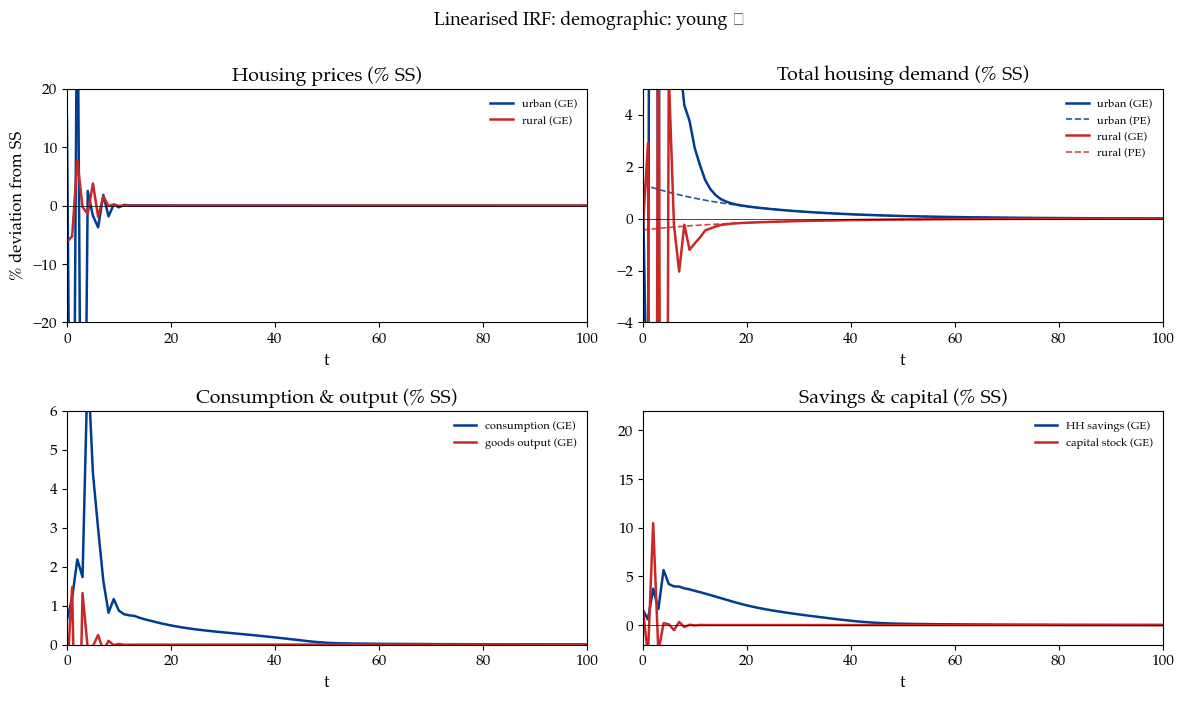

In [107]:
import importlib, transition
importlib.reload(transition)
from transition import linear_irf, make_demographic_shock      # rebind
importlib.reload(plots)
from plots import plot_irf


for name, irf in [('r_world',                irf_r),
                  ('kappa',                  irf_kappa),
                  ('hh_scale (population)',  irf_pop),
                  ('demographic: young ↑',   irf_demo)
                  ]:
    plot_irf(irf, ylim = [
                (-20, 20),        # Housing prices
                (-4, 5),      # Total housing demand
                (0,6),             # Consumption & output — auto
                (-2, 22)],         # Savings & capital
             t_max=100,
             title=f'Linearised IRF: {name} ')

This cell prints Table 5.4 containing cumulative multipliers and the cumulative GE wedge for the four different fundamental shocks:

In [30]:
importlib.reload(transition)
from transition import cumulative_multipliers

results = transition.cumulative_multipliers(
    {
        'Shock to r_t':         irf_r,
        'Shock to N_t':         irf_pop,
        'Shock to ω_{k,t}':     irf_demo,
        'Shock to Kappa':       irf_kappa,
    },
    rho=0.95,     # AR(1) persistence used to derive shock_dev
    eps=0.01,     # impact size (1%)
    do_print=True,
    t_start=10,
)


Cumulative multipliers   m_U = (1−ρ)·Σ_t dU_t / ε  =  Σ_t dU_t / Σ_t dZ_t
------------------------------------------------------------------------------------------
                          PE                         GE                       Wedge       
                        H^u      H^r      q^u      q^r      H^u      H^r      W^u      W^r
------------------------------------------------------------------------------------------
Shock to r_t        -17.186    7.541   -1.652   -0.727    0.201    0.822   -4.368   -7.136
Shock to N_t          6.172    8.431   -0.112    0.011    8.776    7.001    0.181   -0.123
Shock to ω_{k,t}      8.110   -3.695    0.030   -0.003   10.692   -4.910    1.053   -0.203
Shock to Kappa        2.041   -1.108    0.012   -0.001    2.019   -1.094    0.069   -0.005
------------------------------------------------------------------------------------------
(ε, ρ, window) per row:
  Shock to r_t      ε=0.01  ρ=0.95  window=[10, 129)
  Shock to N_t      ε=0.01  ρ

## 6) Robustness check
Here, I implement the robustness check of $\beta=0.97$

In [ ]:

model_beta = copy.deepcopy(model_1992)
model_beta.par.beta = 0.97
model_1992.ss.find_ss_prices(model_beta)    


runs_robust = sim.run_scenarios(
    model_beta, decomposition_scenarios,
    include_baseline=False,        # 'baseline' is named explicitly above
    n_nw_bins=400, year0=1992,
)


  scenario: baseline ...
  scenario: kappa fixed ...
  scenario: real rate fixed ...
  scenario: demographic composition fixed ...
  scenario: population size fixed ...
  scenario: price ratio fixed ...
  scenario: wage fixed ...


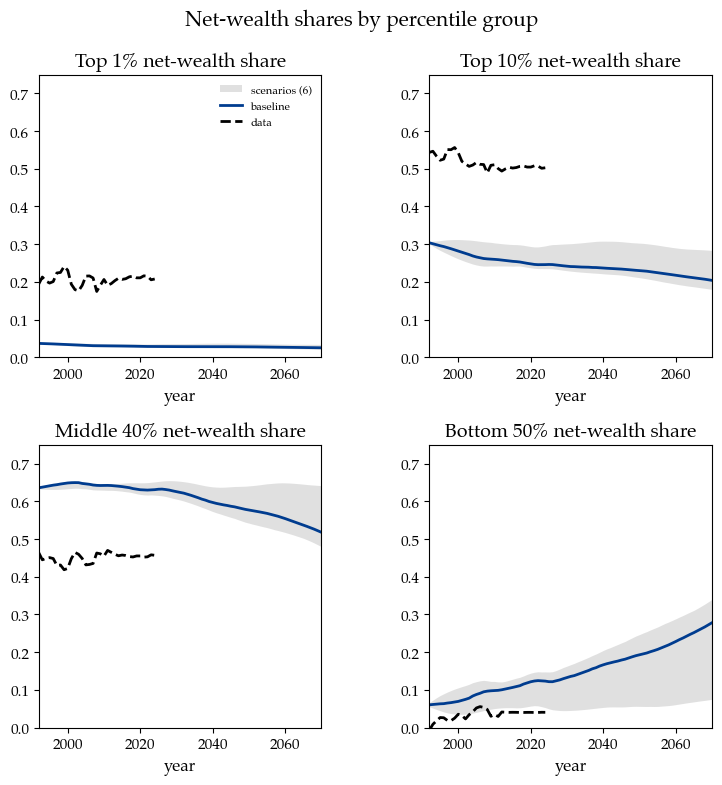

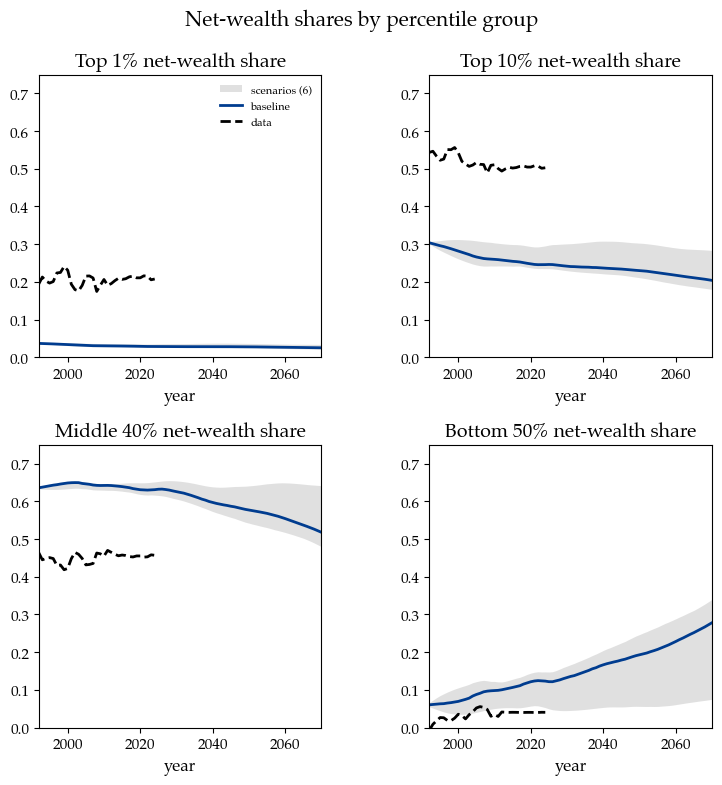

In [ ]:
import simulation as sim
importlib.reload(sim)

sim.plot_wealth_percentiles(runs_robust, xlim=(1992, 2070),ma=0)

## A) Earnings and wealth profiles from MAKRO
Earnings and wealth profiles from MAKRO:

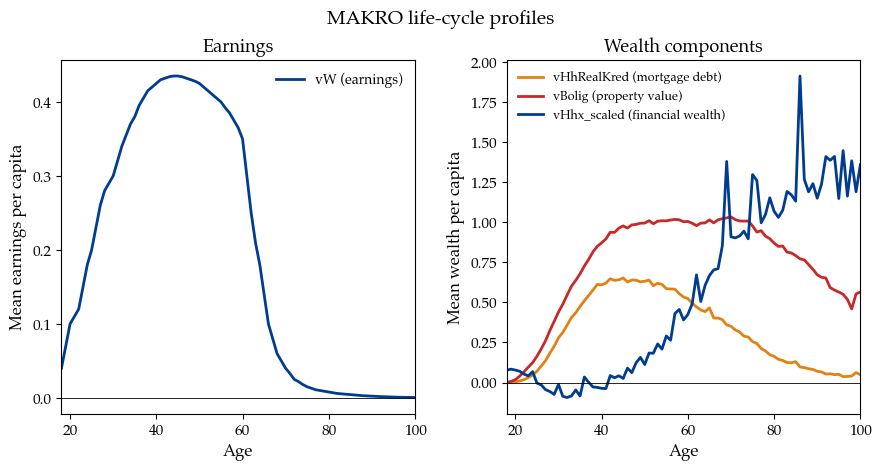

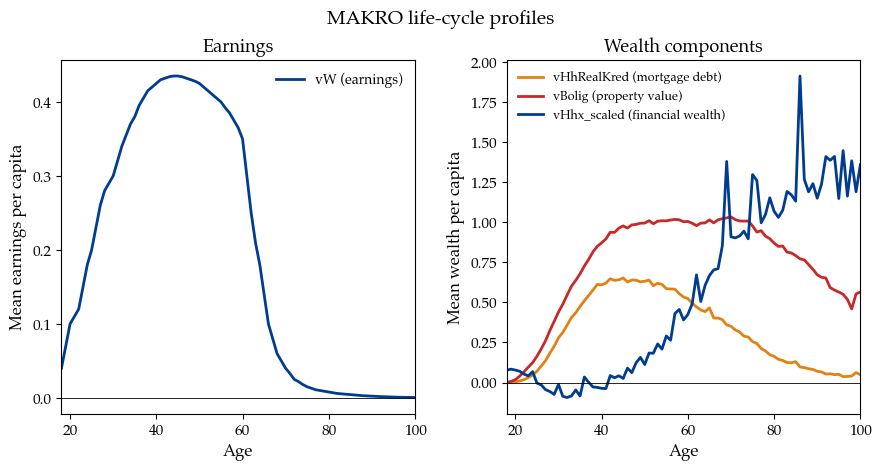

In [114]:
import importlib; importlib.reload(plots)
plots.plot_makro_lifecycle_profiles()                 # finds the xlsx next to plots.py



## B) Partial equilibrium and the DC-EGM algorithm
This section of the code implements the adapted DC-EGM algorithm of Iskhakov et al. (2017). I showcase a partial equilibrium solution with fixed prices. 

/Users/felixwohlert/Desktop/Speciale/Code for thesis/GE model/Version 4.1 (main)/plots.py:281: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


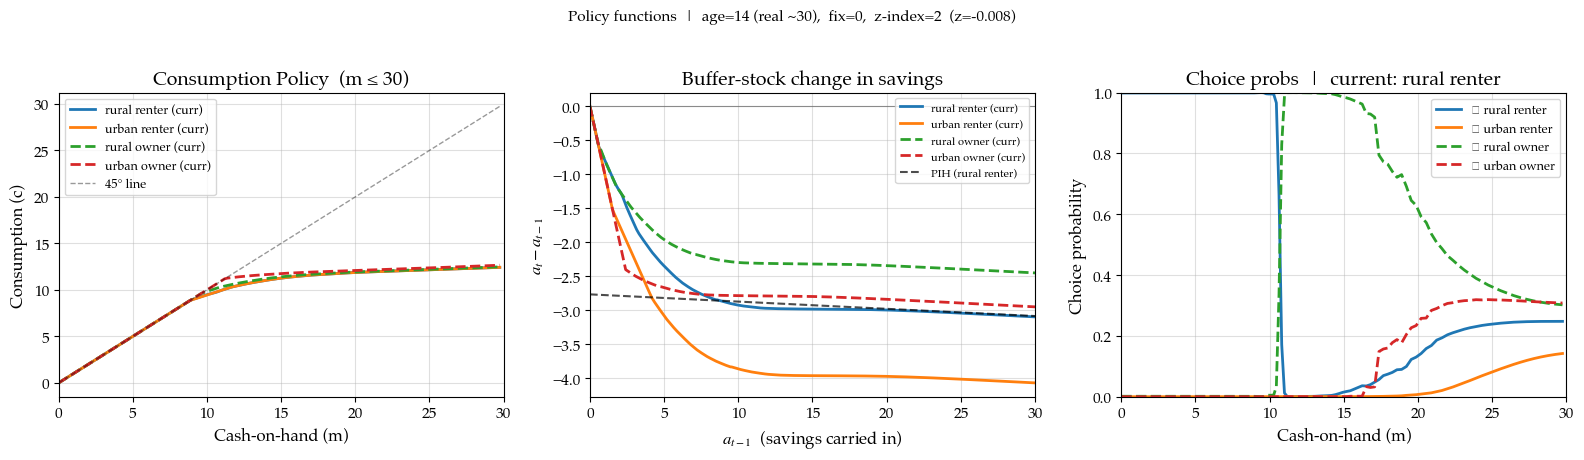

/Users/felixwohlert/Desktop/Speciale/Code for thesis/GE model/Version 4.1 (main)/plots.py:383: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from current font.
  plt.tight_layout()


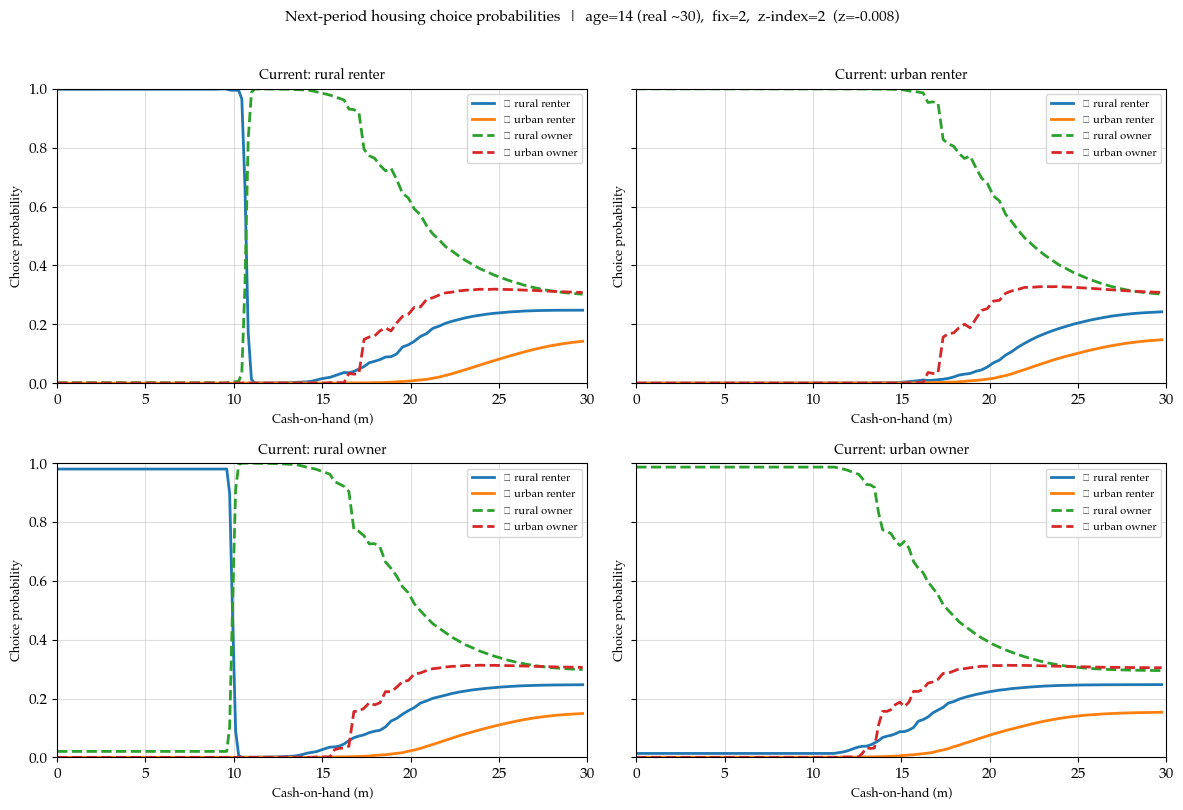

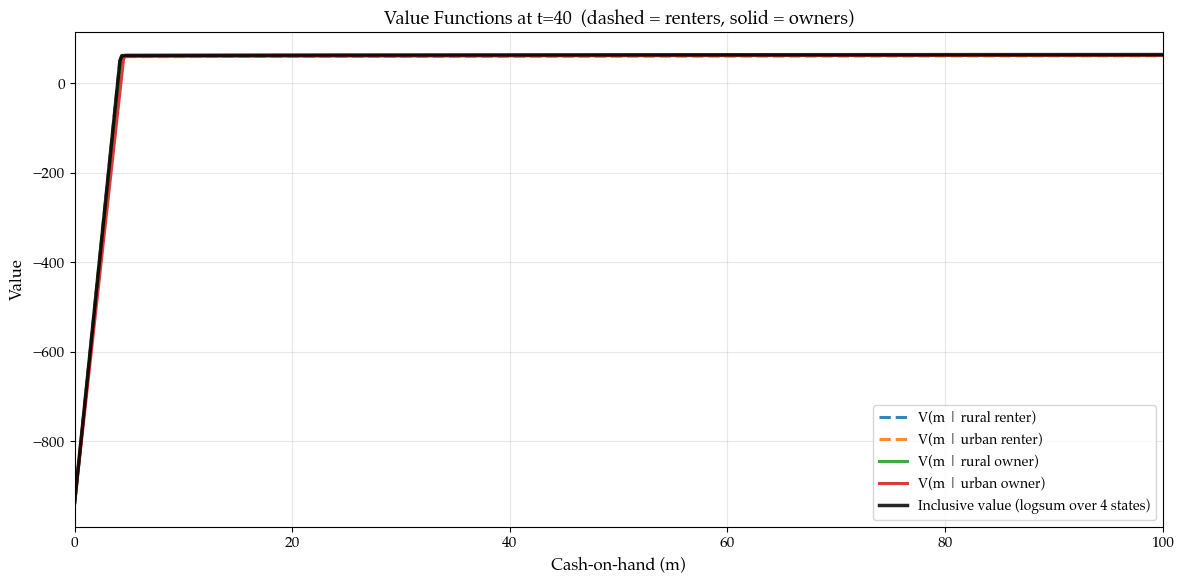

In [26]:
import plots as plots
importlib.reload(plots)
import household_problem



# e. Solving household problem in partial equilibrium
from household_problem import solve_hh_backwards
solve_hh_backwards(model_1992)

model_1992.par.sigma = 1.5


# f. Plotting results
plots.plot_policy(model_1992, age=14, i_fix=0, i_z=2, show_both_states=True, m_max_buffer=30, m_max_consumption=30, m_max_plot=30)

plots.plot_choice_probs(model_1992, age=14, i_fix=2, i_z=2, m_max_plot=30)
# also try age=0, 10, 30, 40 to compare cohorts


#from plots import plot_value_function
plots.plot_value_function(model_1992, t=40, include_logsum=True)


## C) Policy experiments
This section implements a version of the model with taxes and other policies. In particular, I implement four different policies:

1. A profit tax on house sales of $\tau^q=0.15$
2. A wealth tax on house sales of $\tau^h=0.15$
3. A tightening of the regulatory LTV constraint from $\lambda=0.8$ to $0.60$
4. A tighter regulatory control with rental investors/suppliers from $\theta=0.42$ to $0.60$

In [ ]:
import simulation as sim
importlib.reload(sim)
import steady_state as ss
importlib.reload(steady_state)

# a. a tax of 5 per cent on housing sales profits
model_profit_tax = copy.deepcopy(model_1992)
model_profit_tax.par.tau_profits = 0.15
ss.find_ss_prices(model_profit_tax)   

# b. a tax of 5 per cent on the housing value
model_wealth_tax = copy.deepcopy(model_1992)
model_wealth_tax.par.tau_wealth = 0.15
ss.find_ss_prices(model_wealth_tax)      

# c. a tighter regulatory LTV constraint
model_lambda = copy.deepcopy(model_1992)
model_lambda.par.lambda_ltv = 0.60
ss.find_ss_prices(model_lambda)    

# d. a tighter taxation of landlords
model_theta = copy.deepcopy(model_1992)
model_theta.par.theta = 0.60
ss.find_ss_prices(model_theta)    

# e. run
runs_policy = sim.run_scenarios(
    model_1992,
    scenarios = {
        'baseline':    {'model': model_1992,        **baseline_scenario},
        'profit tax':  {'model': model_profit_tax,  **baseline_scenario},
        'wealth tax':  {'model': model_wealth_tax,  **baseline_scenario},
        'tighter LTV': {'model': model_lambda,      **baseline_scenario},
        'tighter rental regulation': {'model': model_theta, **baseline_scenario},
    },
)


# f. plot wealth quantiles
sim.plot_wealth_percentiles(runs_policy, xlim=(1992, 2070),ma=0)

# g. plot policy table:
table = sim.wealth_growth_decomposition_table(
    model_1992,
    scenarios={                       # same dict you gave run_scenarios
        'baseline':                  {'model': model_1992,        **baseline_scenario},
        'profit tax':                {'model': model_profit_tax,  **baseline_scenario},
        'wealth tax':                {'model': model_wealth_tax,  **baseline_scenario},
        'tighter LTV':               {'model': model_lambda,      **baseline_scenario},
        'tighter rental regulation': {'model': model_theta,       **baseline_scenario},
    },
    runs=runs_policy,                 # reuse the pe results you already computed
    col_labels={
        'baseline':                  'Baseline',
        'profit tax':                r'Profit tax, $\tau^q$',
        'wealth tax':                r'Wealth tax, $\tau^h$',
        'tighter LTV':               r'Loan-to-vl., $\lambda$',
        'tighter rental regulation': r'Rent reg., $\theta$',
    },
    latex=True,                       # also prints a paste-ready tabular
)

## C) The Fake News machinery & the non-linear transition path
Some left-overs from all my attempts at computing the full, non-linear solution.

In [27]:
importlib.reload(transition)
from transition import compute_jacobians_complete
importlib.reload(blocks)
import numpy as np

model_terminal = model_1992.copy()

# a. Setting the terminal steady state to have the 2070 age structure (both cohort weights and hh scale)
cw_2070 = np.asarray(cohort_weights_data[-1], dtype=float)   # last data row = 2070
model_terminal.ss.cohort_weights     = cw_2070.copy()
model_terminal.par.cohort_weights_ss = cw_2070.copy()
model_terminal.par.hh_scale = float(hh_scale_data[-1])       # 2070 population scale
model_terminal.ss.hh_scale  = float(hh_scale_data[-1])


# b. Setting the terminal steady state to have the 2070 real rate
model_terminal.ss.r = real_rate_paths_data['baseline'][-1]


# c. Setting the terminal steady state to have the 2070 - kappa
kappa_2070 = 0.0
model_terminal.par.kappa = kappa_2070


# d. Solving the 2070 ss
model_terminal.find_ss_prices(model_terminal, do_print=True)


# Jacobian around the terminal steady state
compute_jacobians_complete(model_terminal, do_print=True)

from plots import plot_hh_jacobians
plots.plot_hh_jacobians(
    model_1992, mode='aggregate',
    outputs=['H_u_hh', 'H_r_hh'],
    inputs=['r', 'q_u', 'q_r'],         
    shock_dates=[0, 20, 40],
    percent_dev=True,                    # rescale to % change in output per 1% shock
    t_max=80,                            
)



par_T = model_1992.par
ss_T  = model_1992.ss

kappa_2070 = 1.0

# a. hh_scale shock from demographics path through 2070
d_hh_scale = hh_scale_full - float(getattr(ss_T, 'hh_scale', 1.0))
d_hh_scale[-T_pad:] = 0.0

# b. Kappa shock path
kappa_2024 = -0.30
kappa_path = np.concatenate([
    np.linspace(model_1992.ss.kappa, kappa_2024, T_data),
    np.full(T_pad, kappa_2070),
])
dKappa_shock = kappa_path - ss_T.kappa
dKappa_shock[-T_pad:] = 0.0
#dKappa_shock[0] = model_1992.par.kappa - kappa_2070 # fix hard coded first-period shock to match the difference between the 1992 and 2070 kappas, since the rest of the path is just a smooth transition from that initial shock to zero


# c. r_world shock relative to terminal SS under selected scenario
dr_world = real_rate_paths_data['baseline'] - float(ss_T.r_world)
dr_world[-T_pad:] = 0.0

# d. Collect shocks for transition solver
shocks_test = {
    'kappa': dKappa_shock,
    'r_world': dr_world,
    'hh_scale': d_hh_scale,
}





  call=   1  r=0.02050  w=1.5709  q_u=0.2679  q_r=0.1195  res_q_u=+1.284e-01  res_q_r=+4.825e-03  |res|=1.284e-01
  call=   2  r=0.02050  w=1.5709  q_u=0.2679  q_r=0.1195  res_q_u=+1.284e-01  res_q_r=+4.825e-03  |res|=1.284e-01
  call=   3  r=0.02050  w=1.5709  q_u=0.2679  q_r=0.1195  res_q_u=+1.284e-01  res_q_r=+4.825e-03  |res|=1.284e-01
  call=   4  r=0.02050  w=1.5709  q_u=0.2679  q_r=0.1195  res_q_u=+1.284e-01  res_q_r=+4.825e-03  |res|=1.284e-01
  call=   5  r=0.02050  w=1.5709  q_u=0.2679  q_r=0.1195  res_q_u=+1.284e-01  res_q_r=+4.825e-03  |res|=1.284e-01
  call=   6  r=0.02050  w=1.5709  q_u=0.2999  q_r=0.1202  res_q_u=+7.530e-03  res_q_r=+2.937e-05  |res|=7.530e-03
  call=   7  r=0.02050  w=1.5709  q_u=0.3020  q_r=0.1202  res_q_u=+7.464e-04  res_q_r=-1.316e-04  |res|=7.464e-04
  call=   8  r=0.02050  w=1.5709  q_u=0.3023  q_r=0.1202  res_q_u=-1.138e-05  res_q_r=+5.029e-06  |res|=1.138e-05
  call=   9  r=0.02050  w=1.5709  q_u=0.3023  q_r=0.1202  res_q_u=+9.023e-08  res_q_r=-3

ValueError: Missing aggregate household Jacobians on model.jac_hh. Compute them first, then call plot_hh_jacobians(mode='aggregate').